In [ ]:
import sys
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import pandas as pd

In [ ]:

# ── Date filter ───────────────────────────────────────────────────────────────
# Pass a date as a command-line argument, e.g.:  python appointment_timeline.py 2025-11-10
# If no argument is given you will be prompted.
filter_date = "2025-11-11"

try:
    filter_date_dt = pd.to_datetime(filter_date).date()
except Exception:
    sys.exit(f"Could not parse date: {filter_date!r}. Use YYYY-MM-DD format.")


In [ ]:
df = pd.read_csv("data/AppointmentDataWeek1.csv")
df.columns = df.columns.str.strip()
df["Appt Time"] = df["Appt Time"].str.strip()

df["start_dt"] = pd.to_datetime(
    df["Appt Date"] + " " + df["Appt Time"], format="%m-%d-%Y %H:%M:%S"
)
df["end_dt"] = df["start_dt"] + pd.to_timedelta(df["Appt Duration"], unit="min")

df = df[df["start_dt"].dt.date == filter_date_dt].copy()

if df.empty:
    sys.exit(f"No appointments found for {filter_date_dt}.")

df = df.sort_values("start_dt").reset_index(drop=True)

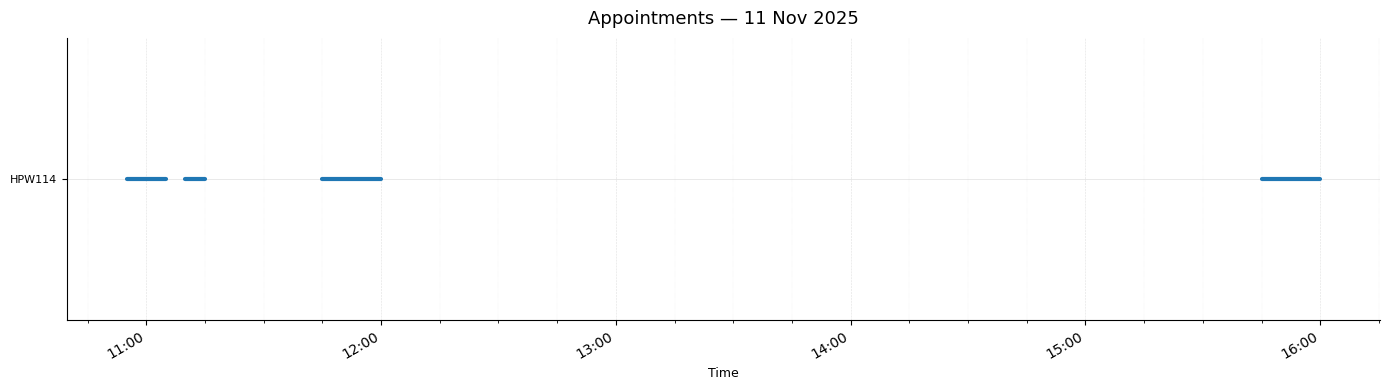

In [ ]:

# ── Colours per provider ──────────────────────────────────────────────────────
providers_unique = df["Primary Provider"].dropna().str.strip().unique()
cmap = plt.colormaps.get_cmap("tab20").resampled(max(len(providers_unique), 2))
PROVIDER_COLOURS = {p: cmap(i) for i, p in enumerate(providers_unique)}

# ── Plot ──────────────────────────────────────────────────────────────────────
provider_list = list(providers_unique)
provider_y = {p: i for i, p in enumerate(provider_list)}
n = len(provider_list)

fig_height = max(4, n * 0.45 + 2)
fig, ax = plt.subplots(figsize=(14, fig_height))

for _, row in df.iterrows():
    provider = str(row["Primary Provider"]).strip()
    y = provider_y[provider]
    colour = PROVIDER_COLOURS[provider]
    ax.plot(
        [row["start_dt"], row["end_dt"]],
        [y, y],
        color=colour,
        linewidth=3,
        solid_capstyle="round",
    )

# ── Y-axis ────────────────────────────────────────────────────────────────────
ax.set_yticks(range(n))
ax.set_yticklabels(provider_list, fontsize=8)
ax.set_ylim(-0.8, n - 0.2)

for y in range(n):
    ax.axhline(y, color="#e0e0e0", linewidth=0.5, zorder=0)

# ── X-axis ────────────────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[15, 30, 45]))
fig.autofmt_xdate(rotation=30, ha="right")

ax.set_xlabel("Time", fontsize=9)
ax.grid(axis="x", which="major", linestyle="--", linewidth=0.4, alpha=0.4)
ax.grid(axis="x", which="minor", linestyle=":", linewidth=0.3, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

ax.set_title(f"Appointments — {filter_date_dt.strftime('%d %b %Y')}", fontsize=13, pad=10)

plt.tight_layout()
out_name = f"appointment_timeline_{filter_date_dt}.png"
# plt.savefig(out_name, dpi=150, bbox_inches="tight")
plt.show()
# print(f"Saved → {out_name}")
